# VIS 2

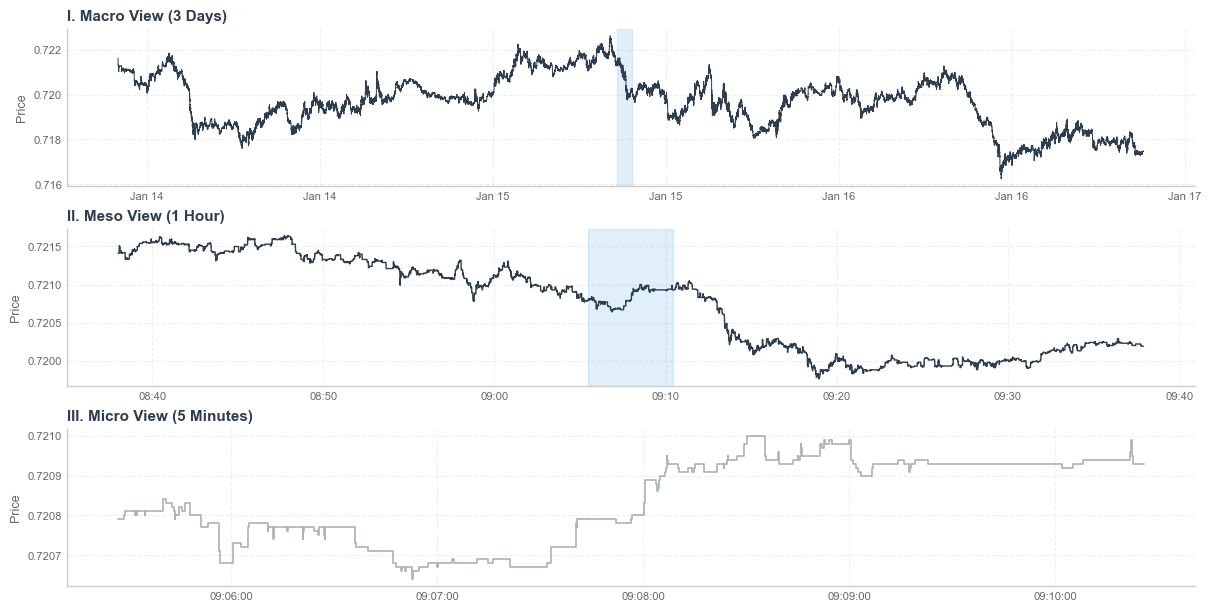

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# --- Visual Configuration ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Inter', 'Arial', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

# Minimalist Palette
MAIN_COLOR = '#2c3e50'  # Deep Slate
ACCENT_COLOR = '#3498db' # Muted Blue for zoom regions
TICK_COLOR = '#e74c3c'   # Muted Red for individual ticks
SPAN_ALPHA = 0.15

file_path = '../data/processed/audusd_dukascopy_ask_201901.parquet'

# 1. Load/Simulate (Same logic as before)
if os.path.exists(file_path):
    df = pd.read_parquet(file_path)
    if 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'])
        df.set_index('datetime', inplace=True)
    df = df.sort_index()
else:
    n_ticks = 100000
    time_deltas = np.random.exponential(scale=2.5, size=n_ticks)
    timestamps = pd.Timestamp('2019-01-02 00:00:00', tz='UTC') + pd.to_timedelta(np.cumsum(time_deltas), unit='s')
    prices = 0.7000 + np.cumsum(np.random.choice([-0.0001, 0.0001, 0.0], size=n_ticks, p=[0.3, 0.3, 0.4]))
    df = pd.DataFrame({'price': prices}, index=timestamps)

# 2. Slicing
anchor_time = df.index[len(df) // 2]
windows = {
    'macro': (anchor_time - pd.Timedelta(days=1.5), anchor_time + pd.Timedelta(days=1.5)),
    'meso': (anchor_time - pd.Timedelta(minutes=30), anchor_time + pd.Timedelta(minutes=30)),
    'micro': (anchor_time - pd.Timedelta(minutes=2.5), anchor_time + pd.Timedelta(minutes=2.5))
}

# 3. Plotting
fig, axes = plt.subplots(3, 1, figsize=(12, 6), constrained_layout=True)

# Panel 1: Macro
ax = axes[0]
df_macro = df.loc[windows['macro'][0]:windows['macro'][1]]
ax.plot(df_macro.index, df_macro['price'], color=MAIN_COLOR, linewidth=0.7)
ax.axvspan(*windows['meso'], color=ACCENT_COLOR, alpha=SPAN_ALPHA)
ax.set_title('I. Macro View (3 Days)', loc='left', fontsize=11, fontweight='bold', color=MAIN_COLOR)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

# Panel 2: Meso
ax = axes[1]
df_meso = df.loc[windows['meso'][0]:windows['meso'][1]]
ax.plot(df_meso.index, df_meso['price'], color=MAIN_COLOR, linewidth=1, drawstyle='steps-post')
ax.axvspan(*windows['micro'], color=ACCENT_COLOR, alpha=SPAN_ALPHA)
ax.set_title('II. Meso View (1 Hour)', loc='left', fontsize=11, fontweight='bold', color=MAIN_COLOR)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Panel 3: Micro
ax = axes[2]
df_micro = df.loc[windows['micro'][0]:windows['micro'][1]]

# The line below draws the "steps-post" blue/gray line
ax.plot(df_micro.index, df_micro['price'], color=MAIN_COLOR, linewidth=1.2, drawstyle='steps-post', alpha=0.4)

# ---> DELETE OR COMMENT OUT THIS LINE <---
# ax.scatter(df_micro.index, df_micro['price'], s=8, color=TICK_COLOR, alpha=0.8, label='Tick Arrival')

ax.set_title('III. Micro View (5 Minutes)', loc='left', fontsize=11, fontweight='bold', color=MAIN_COLOR)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

# General Cleanup
for i, ax in enumerate(axes):
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    
    # Clean up labels
    ax.set_ylabel('Price', fontsize=9, color='#666666')
    ax.tick_params(axis='both', which='major', labelsize=8, colors='#666666')
    
    if i < 2: # Remove x-labels for top two for cleaner look
        ax.set_xlabel('')

# # Annotation for Micro View (simplified)
# mid_idx = len(df_micro) // 2
# axes[2].annotate('Asynchronous Arrivals', 
#                  xy=(df_micro.index[mid_idx], df_micro['price'].iloc[mid_idx]),
#                  xytext=(10, 10), textcoords='offset points',
#                  fontsize=8, color=MAIN_COLOR,
#                  arrowprops=dict(arrowstyle='->', color=MAIN_COLOR, lw=0.5))

# Save
os.makedirs('../plots/eda', exist_ok=True)
plt.savefig('../plots/eda/high_frequency_minimal.pdf', bbox_inches='tight', dpi=300)
plt.show()